In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
  .master("local[*]")\
  .getOrCreate()
sc = spark.sparkContext

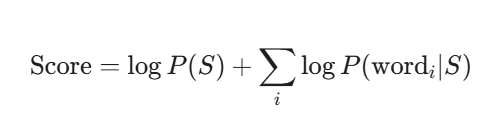

In [2]:
import numpy as np
# 1. 학습된 모델(단어별 스팸 확률) -> Broadcast
model = {"free": 0.3, "win": 0.2, "click": 0.1, "money": 0.4}
prior = 0.5
b_model = sc.broadcast(model)

# 2. 테스트 데이터 (메일 id, 내용)
emails = sc.parallelize([
    (1, "free click win"),
    (2, "hello world") #model에 없는 단어로
])

In [3]:
def calc(text):
  prob_table = b_model.value
  words = text.split()

  # log sum
  log_sum = np.log(prior)
  for w in words:
    p = prob_table.get(w, 1e-10)
    log_sum += np.log(p)
  return log_sum

In [4]:
scores = emails.mapValues(calc)
print(scores.collect())

[(1, np.float64(-5.809142990314027)), (2, np.float64(-46.744849040440855))]
